In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

from srm.config import _icechunk_storage_for_path
from srm.qa_flags import discover_leaves, get_data, parse_tag

In [9]:
SUMMARY_CSV = "qa_flag_summary_v0.14.1.csv"

In [10]:
from srm.qa_flags import ATTRS_TIME_INVARIANT, ATTRS_TIME_VARYING

flag_time_invariant_name = ATTRS_TIME_INVARIANT["short_name"]
flag_time_varying_name = ATTRS_TIME_VARYING["short_name"]

In [11]:
VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]

GCMS = ["CESM2-WACCM6", "UKESM1-1-LL"]

BRANCH = "v0.14.1"
ROOT_DIR = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/"
STORE_SUBSET_ID = "global"

In [12]:
import logging

logging.basicConfig(level=logging.INFO)

# Option 1: call `run_step4` function (goes through all steps at once, for both downscaled and debiased coarse)

In [6]:
from srm.qa_flags import run_step4

In [ ]:
run_step4(
    gcms=GCMS,
    branch=BRANCH,
    root_dir=ROOT_DIR,
    store_subset_id=STORE_SUBSET_ID,
    summary_csv_base_fname=SUMMARY_CSV,
    verbose=True,
    mode="both",
)

INFO:srm.qa_flags:Discovering leaves of the data tree...
/scratch/synced/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/scratch/synced/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/scratch/synced/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/scratch/synced/src/sr

# Option 2: go through each step one at a time (just for downscaled, not including debiased coarse in this demo)

### A. Define what data arrays exist to traverse

In [ ]:
[trees, tags, _, _, _, tags_np, _, _] = discover_leaves(
    gcms=GCMS, branch=BRANCH, root_dir=ROOT_DIR, store_subset_id=STORE_SUBSET_ID, is_downscaled=True
)

repos: dict[str, icechunk.Repository] = {}
for gcm in GCMS:
    repos[gcm] = icechunk.Repository.open(
        _icechunk_storage_for_path(f"{ROOT_DIR}{gcm}-ERA5-{STORE_SUBSET_ID}.icechunk")
    )

### B. Create CSV summarizing flag prevalence

In [7]:
from srm.qa_flags import calculate_land_mask

In [ ]:
example_tag = tags[0]

land_mask = calculate_land_mask(
    example_tag=example_tag,
    trees=trees,
    is_downscaled=True,
    var_to_analyze=flag_time_invariant_name,
)

land_mask.load()

land_mask_u8 = land_mask.astype(np.uint8)  # 0/1, still 1 byte

In [ ]:
land_mask_u8.plot()

In [10]:
from srm.qa_flags import calculate_summary_stats

In [ ]:
calculate_summary_stats(
    tags=tags,
    trees=trees,
    flag_time_varying_name=flag_time_varying_name,
    flag_time_invariant_name=flag_time_invariant_name,
    land_mask_u8=land_mask_u8,
    summary_csv_fname=SUMMARY_CSV,
    is_downscaled=True,
    verbose=True,
)

# Read in summary CSVs and make summary figure

In [2]:
import coiled
from frisky import hijack

cluster = coiled.Cluster(
    name="srm-qaqc-flags-nrh",
    region="us-west-2",
    n_workers=12,
    worker_vm_types=["m8gn.xlarge"],
    scheduler_vm_types="c8g.xlarge",
    spot_policy="spot_with_fallback",
    use_best_zone=True,
    tags={"Project": "SRM"},
    worker_options={"nthreads": 8},
    environ={"ZARR_ASYNC__CONCURRENCY": "128"},
)

client = hijack(cluster.get_client())
client

[2026-09-07 22:17:18,553][INFO    ][coiled] Fetching latest package priorities...
[2026-09-07 22:17:18,553][INFO    ][coiled.package_sync] Resolving your local /Users/clairezarakas/Documents/science/srm-downscaling/uv.lock Python environment...
[2026-09-07 22:17:18,817][INFO    ][coiled.package_sync] Scanning 293 python packages...
[2026-09-07 22:17:19,090][INFO    ][coiled] Running pip check...
[2026-09-07 22:17:19,364][INFO    ][coiled] Validating environment...
[2026-09-07 22:17:20,587][INFO    ][coiled] Creating wheel for ~/Documents/science/srm-downscaling/src...
[2026-09-07 22:17:20,686][INFO    ][coiled] Creating wheel for srm...
[2026-09-07 22:17:22,415][INFO    ][coiled] Uploading coiled_local_src...
[2026-09-07 22:17:25,807][INFO    ][coiled] Uploading srm...
[2026-09-07 22:17:26,937][INFO    ][coiled] Creating software environment...
[2026-09-07 22:17:28,086][INFO    ][coiled] Creating Cluster (name: srm-qaqc-flags-nrh, https://cloud.coiled.io/clusters/2019832 ). This usuall

<frisky.Client: scheduler="wss://cluster-cclbb.dask.host/Cv7n1pKgw4RTpdcA/frisky-comm?__frisky_dial_host=52.24.183.73" id="client-0">

In [57]:
metrics = [
    ("frac_flagged_time_varying", "time varying: fraction of pixel-days flagged total"),
    ("land_frac_flagged_time_varying", "time varying: land fraction of pixel-days flagged total"),
    (
        "frac_space_flagged_time_varying",
        "time varying: frac of pixels with at least one timestep flagged",
    ),
    (
        "land_frac_space_flagged_time_varying",
        "time varying: frac of land pixels with at least one timestep flagged",
    ),
    ("frac_space_flagged_time_invariant", "time-invariant: frac space flagged"),
    ("land_frac_space_flagged_time_invariant", "time-invariant: land frac space flagged"),
]

In [58]:
# NOTE: SUMMARY_CSV already includes ".csv", so run_step4 (Option 1, above) writes these
# with a double extension. Matching that here rather than renaming SUMMARY_CSV itself,
# since that variable is also used above this section (Option 1 and Option 2).
summary_downscaled = pd.read_csv(f"{SUMMARY_CSV}_downscaled.csv")
summary_coarse = pd.read_csv(f"{SUMMARY_CSV}_debiased_coarse.csv")

VARIABLE_ORDER = ["pr", "rsds", "tas", "tasmax", "tasmin"]
GCM_ORDER = GCMS

In [59]:
from matplotlib.lines import Line2D


def plot_flag_summary_scatter(
    df,
    metrics,
    gcm_order=GCM_ORDER,
    variable_order=VARIABLE_ORDER,
    ylabel="fraction",
    is_delta=False,
    suptitle=None,
    savefig=None,
):
    """
    Scatter-plot each (column, label) in `metrics`, x-axis grouped by
    (gcm, variable) -- e.g. "CESM2-WACCM6 / tasmax", "CESM2-WACCM6 / pr", ...,
    "UKESM1-1-LL / tasmax", ... -- colored by scenario. A vertical dashed
    line marks each boundary between one gcm's block of x-positions and the
    next.

    If is_delta is True, points are filled where the value is negative and
    hollow where it's >= 0 (so a sign flip is visible at a glance), and a
    horizontal y=0 dashed reference line is drawn -- with the row's y-limits
    explicitly computed to include 0, since a row whose actual data never
    crosses zero would otherwise autoscale to a range that excludes it
    entirely. Drawn in black, above the data (not gray/zorder=0 like the gcm
    boundary line), since gray-and-behind-the-data made it easy to miss
    against the grid and the gcm boundary line's identical styling.
    Otherwise every point is drawn hollow.

    y-axis is shared within each row (row 0's two panels are the all-space
    and land-only versions of the same metric, etc.) but not between rows,
    since different rows are different metrics with different natural
    ranges; also not shared across separate calls to this function, so e.g.
    the bcsd and qdmsd figures from two separate calls can end up on
    different y-scales from each other.
    """
    gcm_var = [
        (gcm, var)
        for gcm in gcm_order
        for var in variable_order
        if ((df["gcm"] == gcm) & (df["variable"] == var)).any()
    ]
    pos = {gv: i for i, gv in enumerate(gcm_var)}
    gcm_boundaries = [i - 0.5 for i in range(1, len(gcm_var)) if gcm_var[i][0] != gcm_var[i - 1][0]]

    scenarios = df["scenario"].unique().tolist()
    palette = dict(zip(scenarios, sns.color_palette(n_colors=len(scenarios))))
    palette["historical"] = "black"

    GROUP_SPREAD = 0.15  # distance between scenario clusters within a gcm/variable's x position
    JITTER_WIDTH = 0.04  # random scatter within each scenario's own cluster
    scenario_offset = {
        s: (i - (len(scenarios) - 1) / 2) * GROUP_SPREAD for i, s in enumerate(scenarios)
    }
    rng = np.random.default_rng(0)

    fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharey="row")
    axes = axes.flatten()

    for ax, (col, label) in zip(axes, metrics):
        for s in scenarios:
            sub = df[df["scenario"] == s]
            x_base = np.array([pos[(g, v)] for g, v in zip(sub["gcm"], sub["variable"])])
            x = x_base + scenario_offset[s] + rng.uniform(-JITTER_WIDTH, JITTER_WIDTH, len(sub))
            if is_delta:
                neg = sub[col] < 0
                ax.scatter(
                    x[neg],
                    sub[col][neg],
                    marker="o",
                    facecolors=palette[s],
                    edgecolors=palette[s],
                    linewidths=1.5,
                    s=80,
                    label=s,
                )
                ax.scatter(
                    x[~neg],
                    sub[col][~neg],
                    marker="o",
                    facecolors="none",
                    edgecolors=palette[s],
                    linewidths=1.5,
                    s=80,
                )
            else:
                ax.scatter(
                    x,
                    sub[col],
                    marker="o",
                    facecolors="none",
                    edgecolors=palette[s],
                    linewidths=1.5,
                    s=80,
                    label=s,
                )
        ax.set_xticks(range(len(gcm_var)))
        ax.set_xticklabels([f"{g}\n{v}" for g, v in gcm_var], rotation=45, ha="right")
        ax.set_title(label)
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        ax.grid()
        for b in gcm_boundaries:
            ax.axvline(b, color="gray", lw=0.8, ls="--", zorder=0)
        if is_delta:
            ax.axhline(0, color="black", lw=1.3, ls="--", zorder=10)

    if is_delta:
        # Compute each row's y-limits directly from that row's own two metrics'
        # actual data (not from ax.get_ylim(), whose autoscaled value may not
        # yet reflect sharey="row"'s final range at this point) and explicitly
        # widen to include 0, then set it -- set_ylim propagates immediately to
        # every axis sharing that row, unlike relying on autoscaling alone.
        for row_start in range(0, len(metrics), 2):
            row_cols = [c for c, _ in metrics[row_start : row_start + 2]]
            row_values = pd.concat([df[c] for c in row_cols])
            data_min, data_max = min(row_values.min(), 0), max(row_values.max(), 0)
            pad = 0.05 * (data_max - data_min) if data_max > data_min else 0.01
            for ax in axes[row_start : row_start + 2]:
                ax.set_ylim(data_min - pad, data_max + pad)

    handles, labels = axes[0].get_legend_handles_labels()
    if is_delta:
        handles = handles + [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markersize=9,
                markerfacecolor="gray",
                markeredgecolor="gray",
                label="delta < 0 (filled)",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markersize=9,
                markerfacecolor="none",
                markeredgecolor="gray",
                label="delta >= 0 (hollow)",
            ),
        ]
        labels = labels + [h.get_label() for h in handles[-2:]]

    if suptitle:
        fig.suptitle(suptitle, y=1.05, fontsize=14)
    fig.legend(
        handles,
        labels,
        title="scenario",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0 if suptitle else 1.04),
        ncol=len(handles),
    )
    plt.tight_layout(rect=[0, 0, 1, 0.93 if suptitle else 0.95])
    if savefig:
        plt.savefig(savefig, dpi=150, bbox_inches="tight")
    plt.show()


def compute_metric_delta(
    df,
    discriminator_col,
    value_b,
    value_a,
    metrics,
    match_cols=("gcm", "variable", "scenario", "ensemble_member"),
):
    """
    Return `value_b`'s rows minus `value_a`'s rows for every metric in
    `metrics`, matched on `match_cols` (default: everything that identifies
    "the same run" except `discriminator_col` itself).

    e.g. compute_metric_delta(summary_downscaled, "method", "qdmsd", "bcsd", metrics)
    gives qdmsd - bcsd for every matching (gcm, variable, scenario,
    ensemble_member) pair within the downscaled grid.

    This is an inner join: a row present under `value_a` but not `value_b`
    (or vice versa) is silently dropped, not treated as a missing/NaN delta
    -- the printed match count is a quick sanity check for that.
    """
    df_a = df[df[discriminator_col] == value_a]
    df_b = df[df[discriminator_col] == value_b]
    merged = df_a.merge(df_b, on=list(match_cols), suffixes=("_a", "_b"))
    print(
        f"{discriminator_col}={value_b!r} vs {value_a!r}: {len(merged)} matched rows (out of {len(df_a)} / {len(df_b)})"
    )
    out = merged[list(match_cols)].copy()
    for col, _ in metrics:
        out[col] = merged[f"{col}_b"] - merged[f"{col}_a"]
    return out

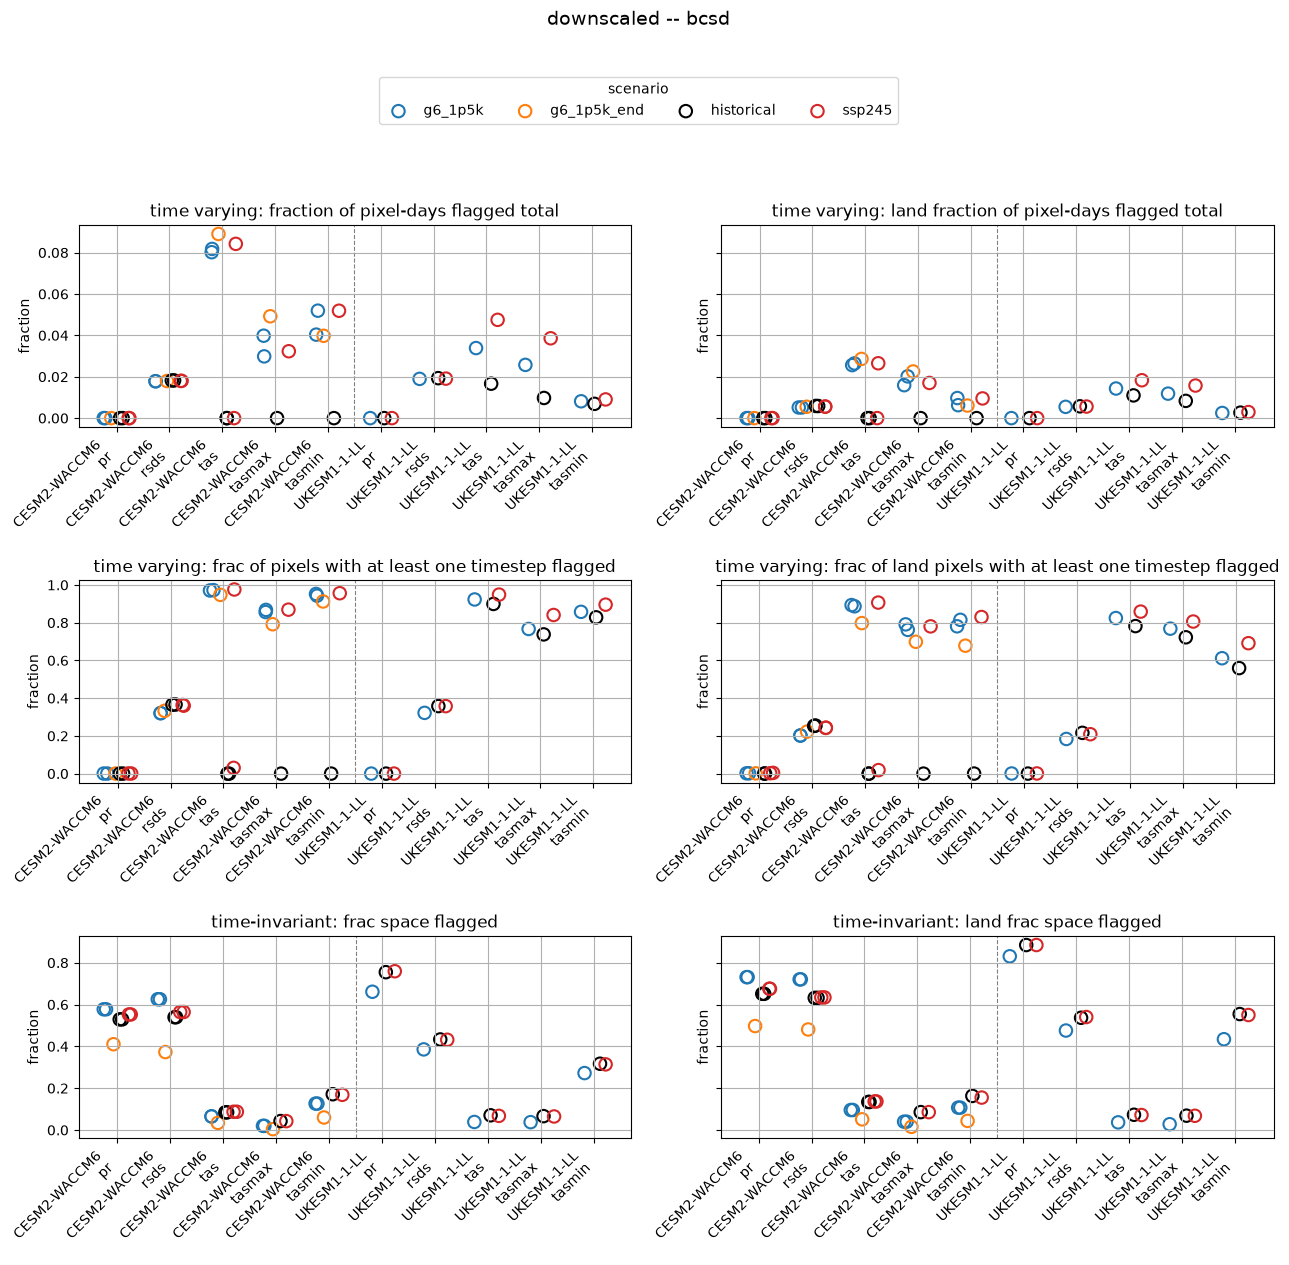

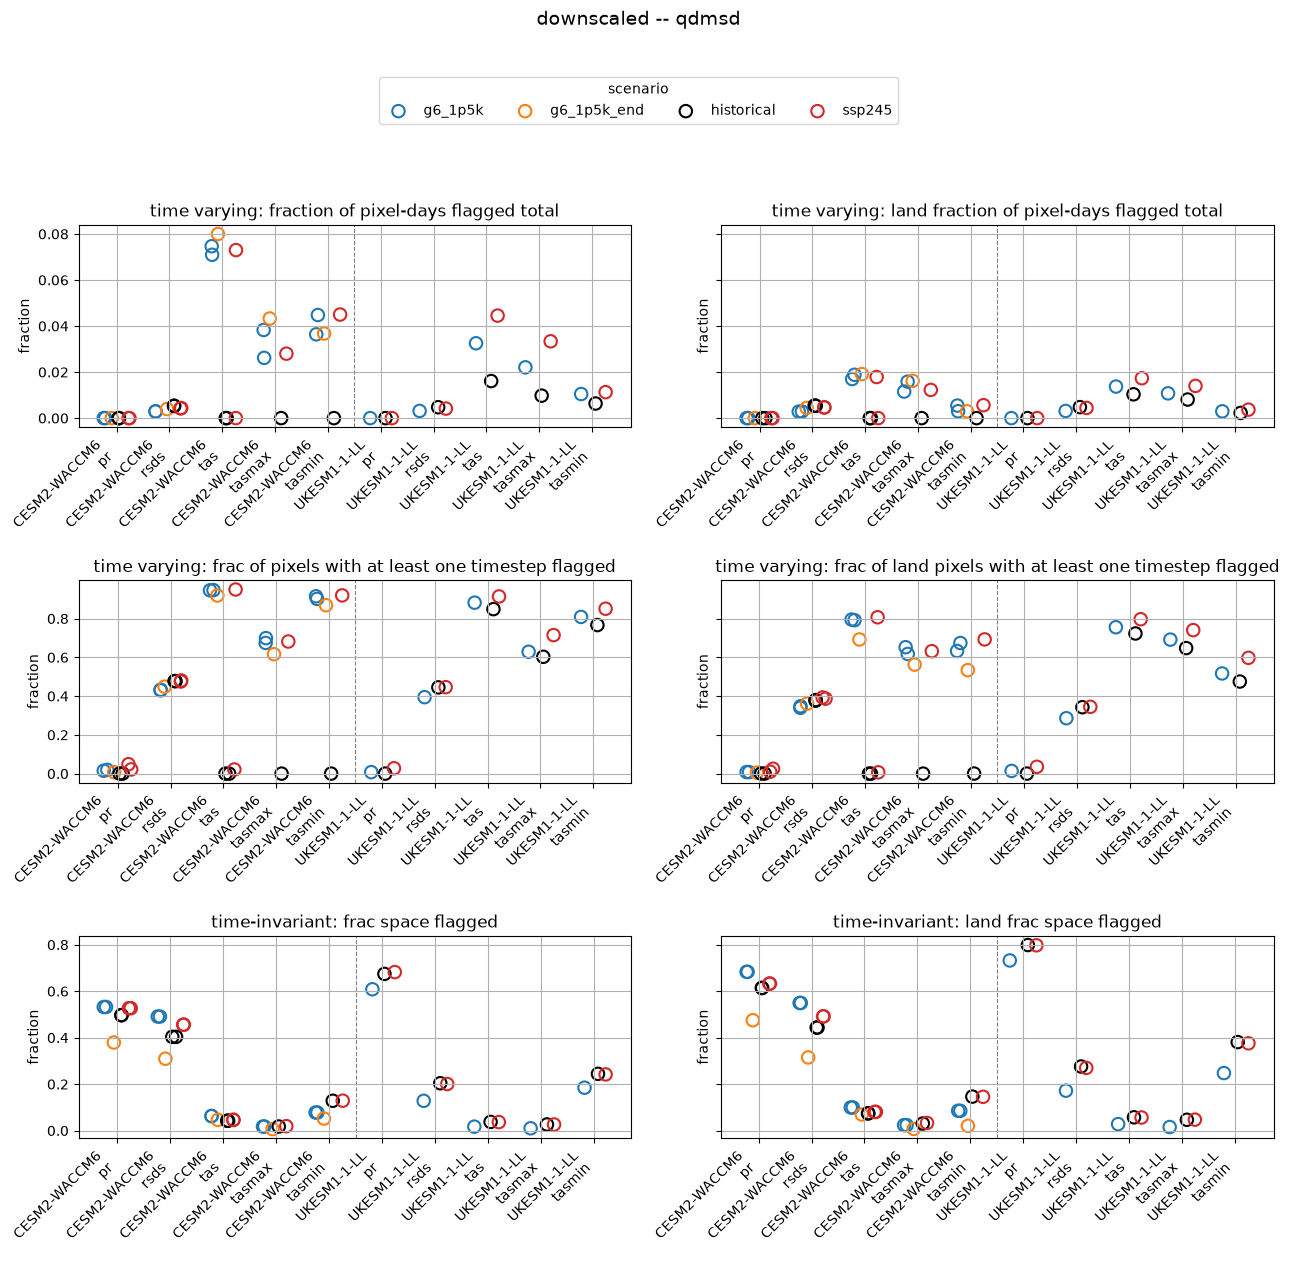

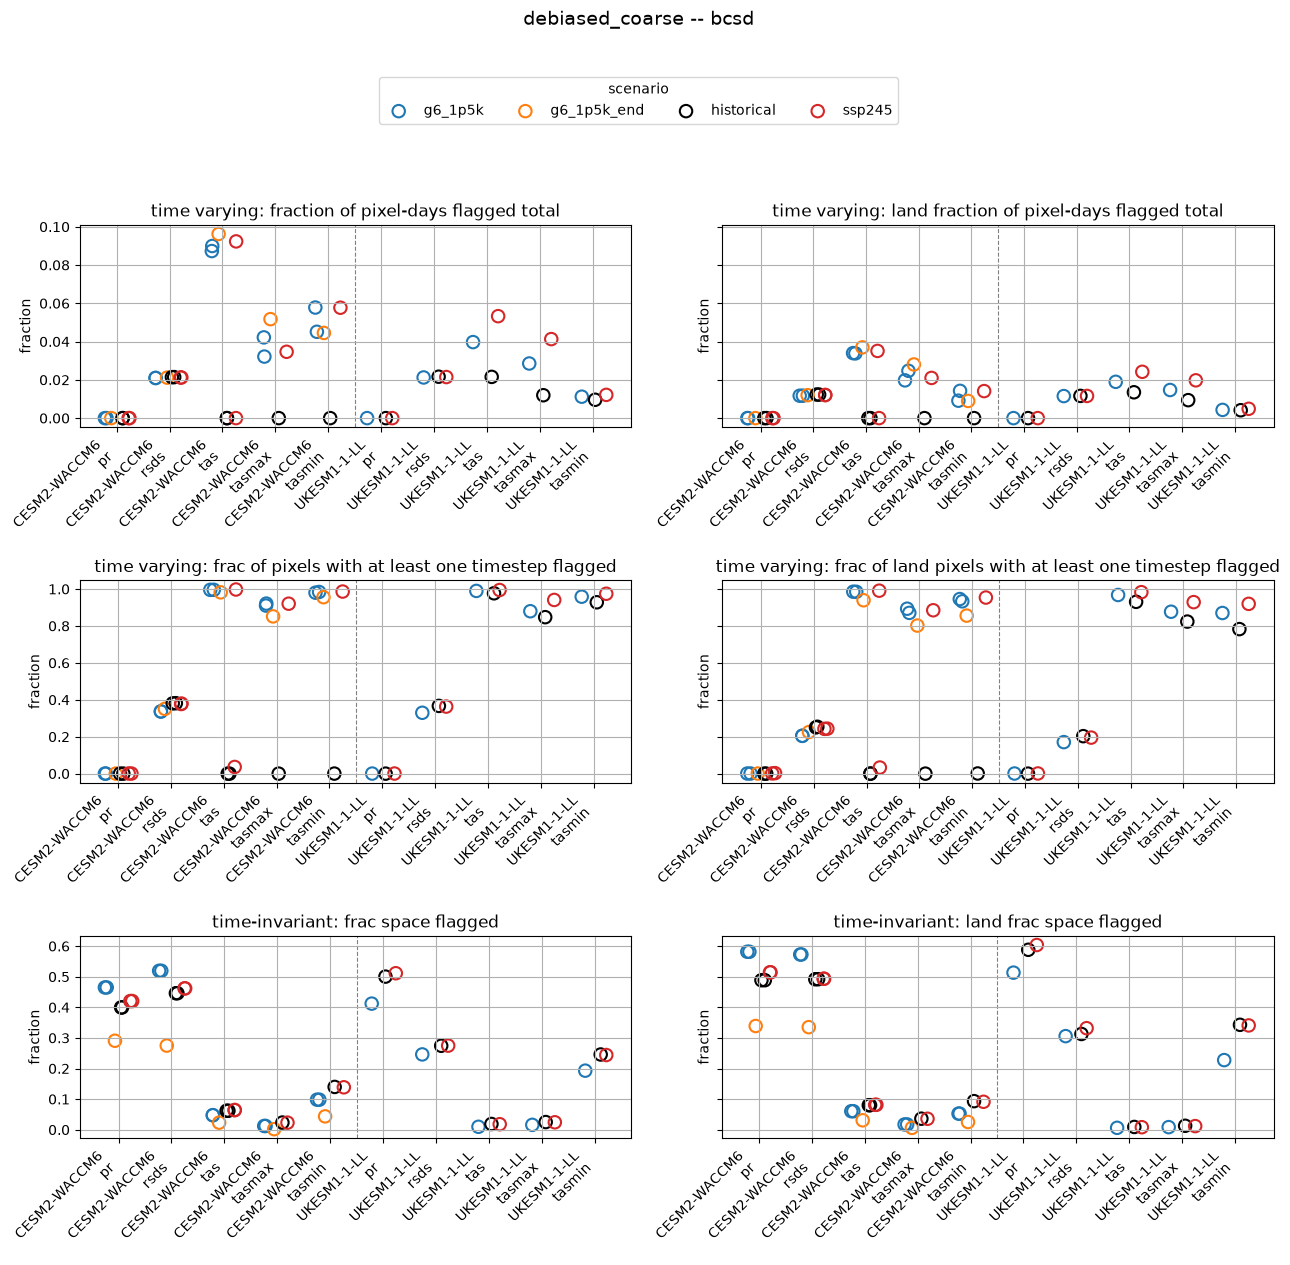

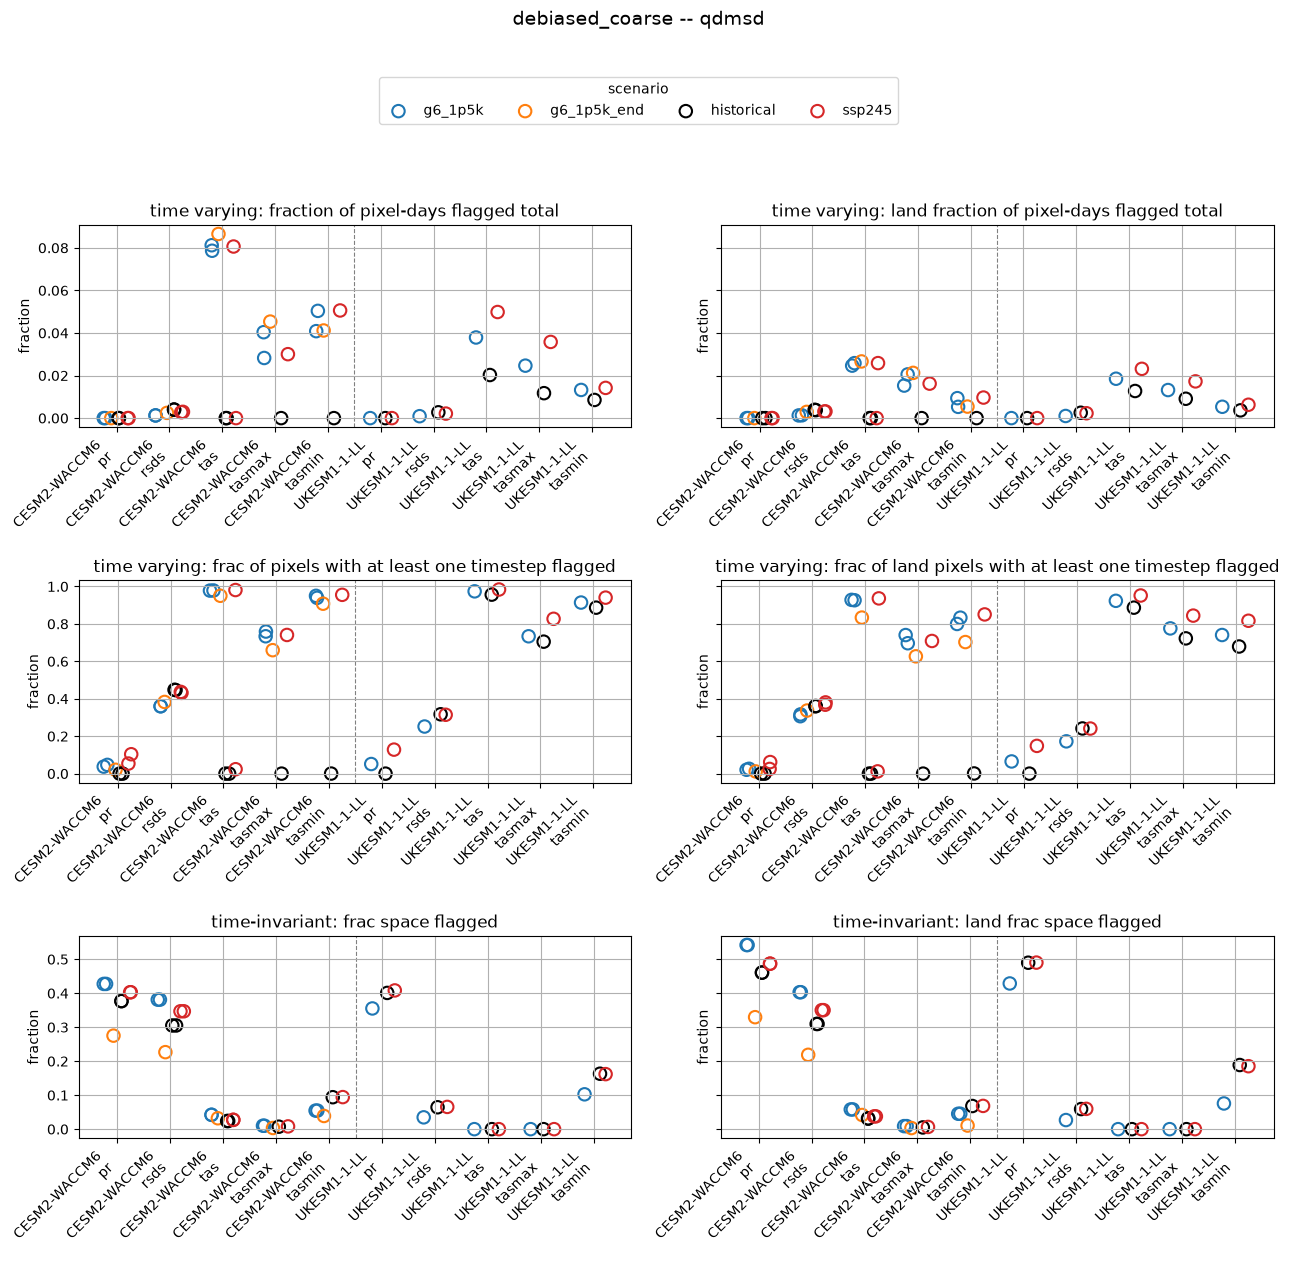

In [60]:
# Base plots: absolute values, one figure per (resolution, method)
for resolution_label, df in [
    ("downscaled", summary_downscaled),
    ("debiased_coarse", summary_coarse),
]:
    for method in ["bcsd", "qdmsd"]:
        sub = df[df["method"] == method]
        plot_flag_summary_scatter(
            sub,
            metrics,
            suptitle=f"{resolution_label} -- {method}",
        )

method='qdmsd' vs 'bcsd': 46 matched rows (out of 46 / 46)


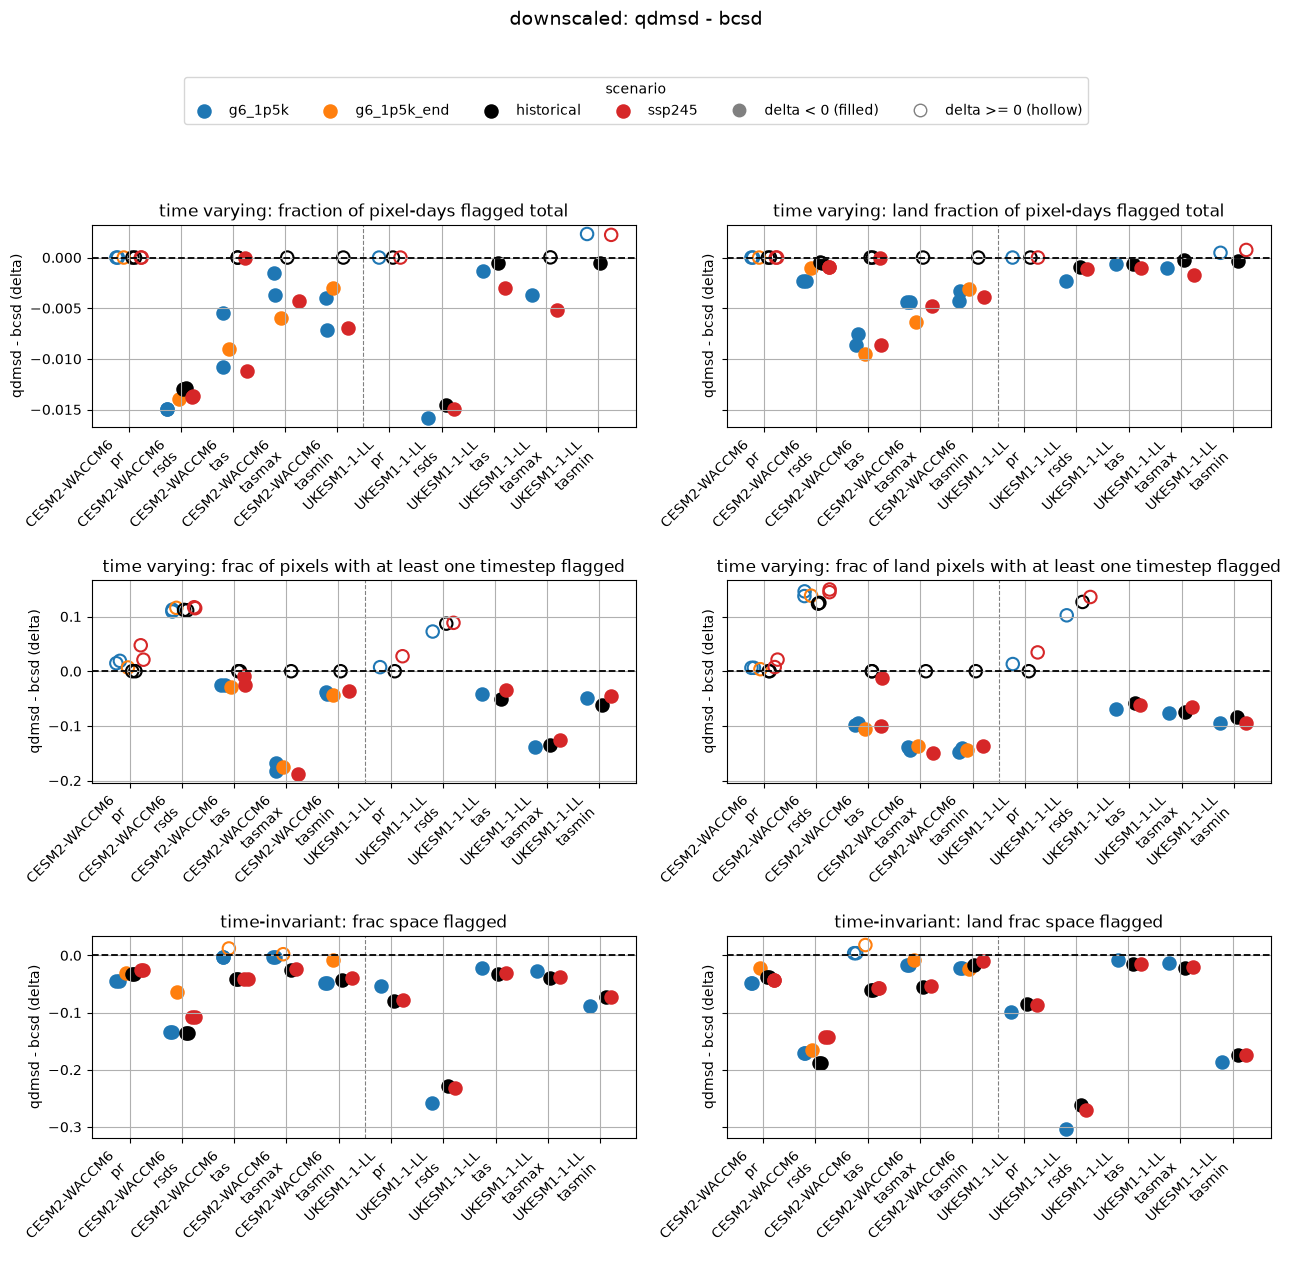

method='qdmsd' vs 'bcsd': 46 matched rows (out of 46 / 46)


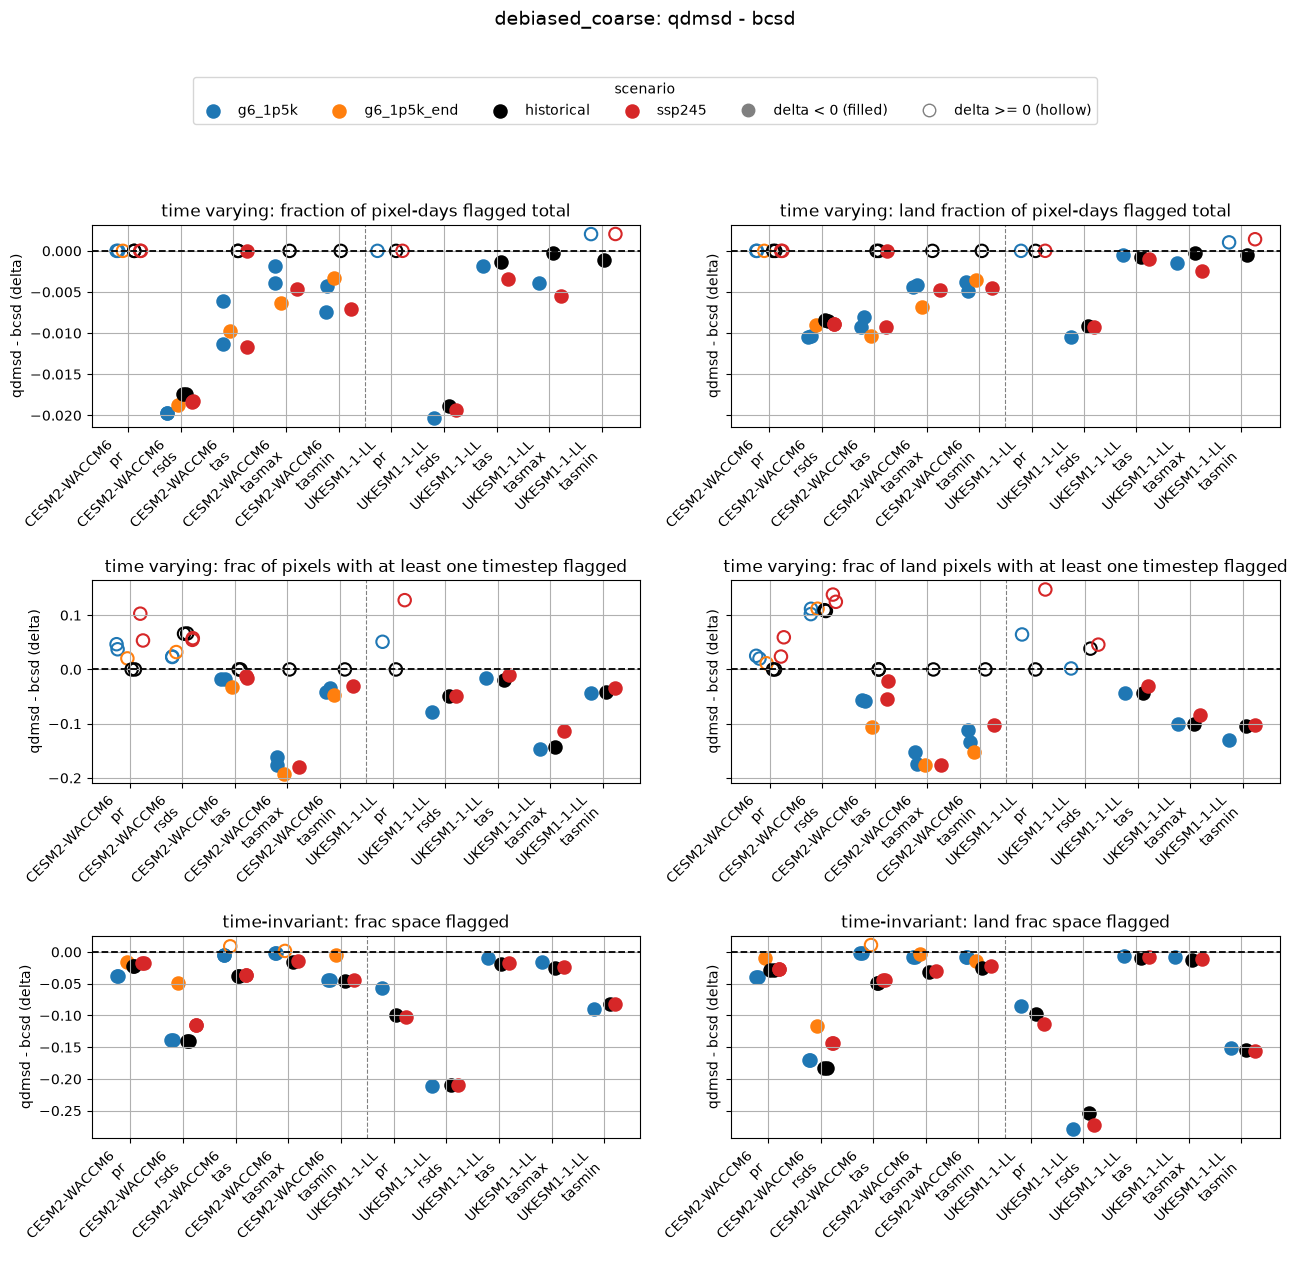

In [61]:
# Method delta: qdmsd - bcsd, within each resolution
for resolution_label, df in [
    ("downscaled", summary_downscaled),
    ("debiased_coarse", summary_coarse),
]:
    delta_df = compute_metric_delta(
        df, discriminator_col="method", value_b="qdmsd", value_a="bcsd", metrics=metrics
    )
    plot_flag_summary_scatter(
        delta_df,
        metrics,
        ylabel="qdmsd - bcsd (delta)",
        is_delta=True,
        suptitle=f"{resolution_label}: qdmsd - bcsd",
        savefig=f"qdmsd_minus_bcsd_delta_{resolution_label}.png",
    )

resolution='downscaled' vs 'debiased_coarse': 46 matched rows (out of 46 / 46)


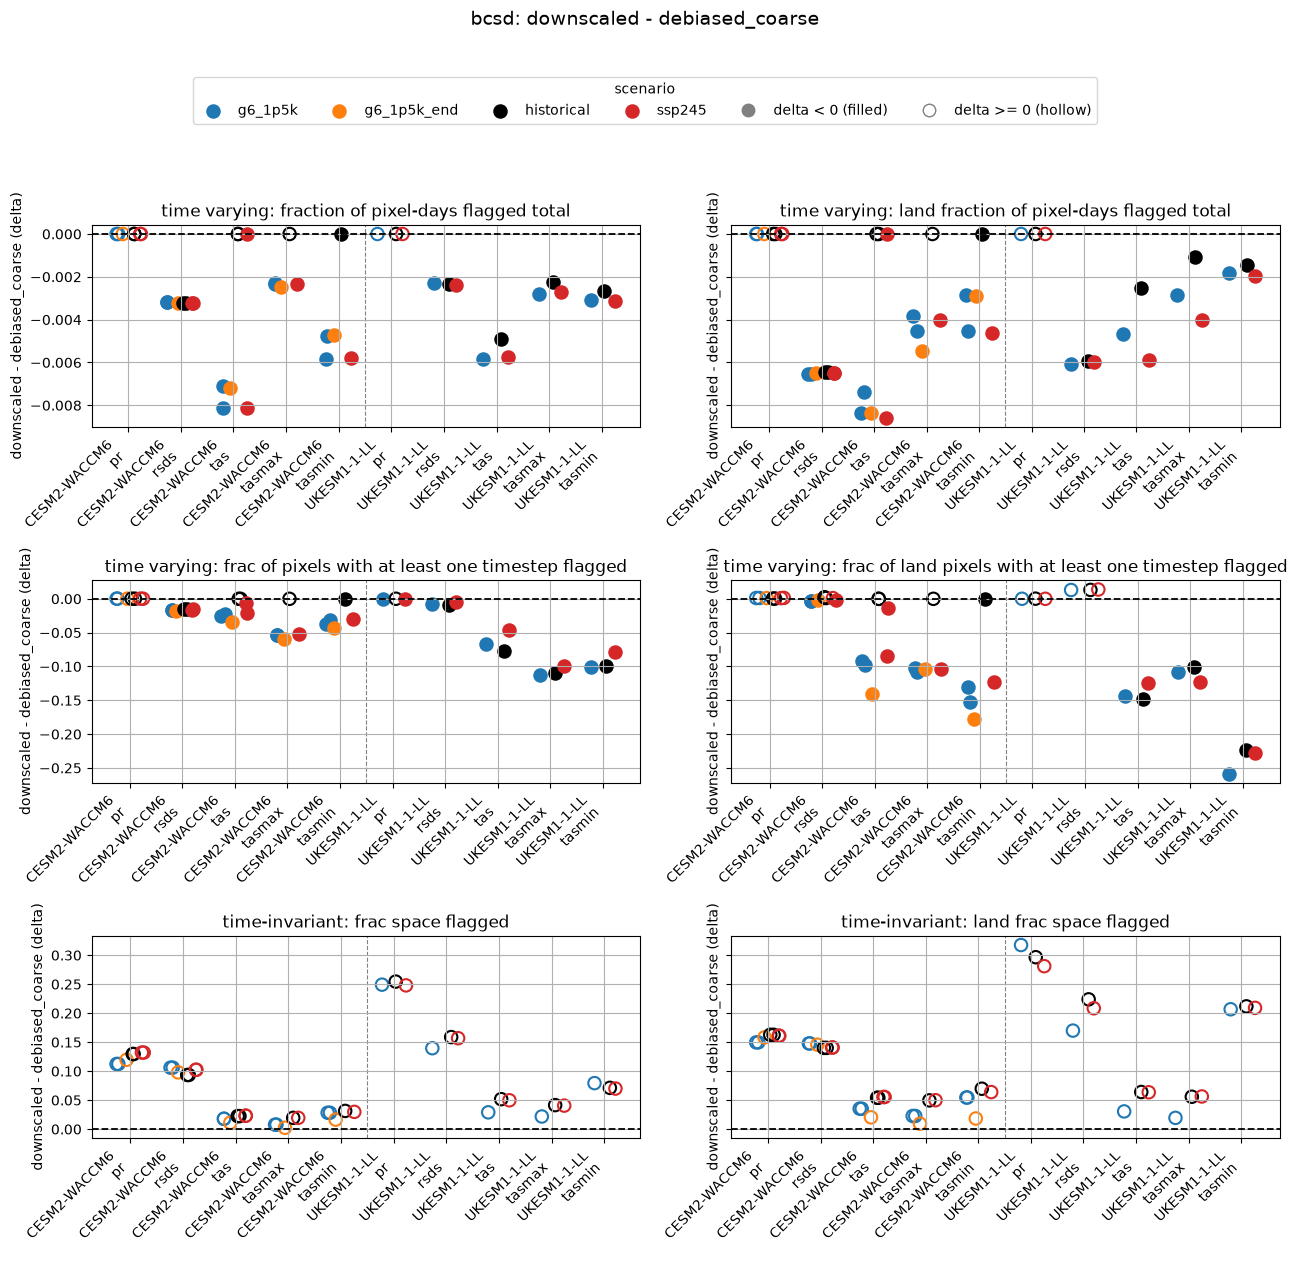

resolution='downscaled' vs 'debiased_coarse': 46 matched rows (out of 46 / 46)


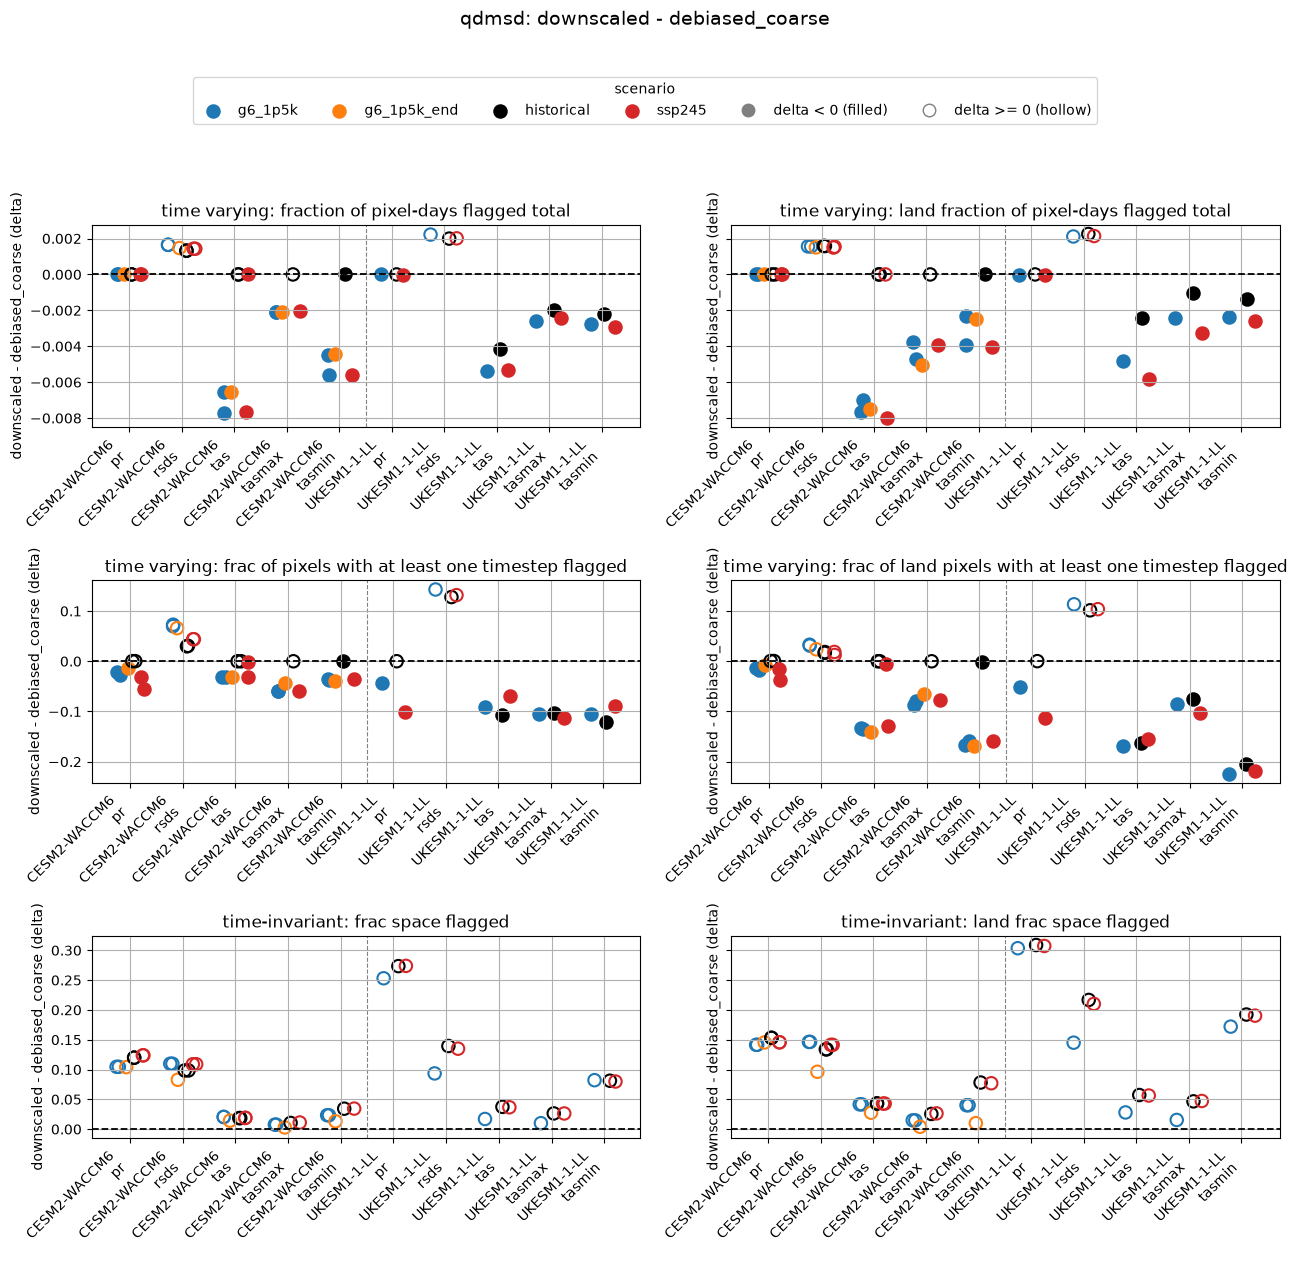

In [62]:
# Resolution delta: downscaled - debiased_coarse, within each method (positive = more flagged in downscaled)
summary_combined = pd.concat([summary_downscaled, summary_coarse], ignore_index=True)
for method in ["bcsd", "qdmsd"]:
    by_method = summary_combined[summary_combined["method"] == method]
    delta_df = compute_metric_delta(
        by_method,
        discriminator_col="resolution",
        value_b="downscaled",
        value_a="debiased_coarse",
        metrics=metrics,
    )
    plot_flag_summary_scatter(
        delta_df,
        metrics,
        ylabel="downscaled - debiased_coarse (delta)",
        is_delta=True,
        suptitle=f"{method}: downscaled - debiased_coarse",
        savefig=f"downscaled_minus_debiased_coarse_delta_{method}.png",
    )

# D. Evaluate flag hotspots

In [6]:
from srm.qa_flags import discover_leaves

In [13]:
[trees, tags, _, _, _, tags_np, _, _] = discover_leaves(
    gcms=GCMS, branch=BRANCH, root_dir=ROOT_DIR, store_subset_id=STORE_SUBSET_ID, is_downscaled=True
)

for i, tag in enumerate(tags):
    flag_time_varying = get_data(
        tag=tag, trees=trees, var_to_analyze=flag_time_varying_name, is_downscaled=True
    )
    flag_time_invariant = get_data(
        tag=tag, trees=trees, var_to_analyze=flag_time_invariant_name, is_downscaled=True
    )
    if i == 0:
        flag_time_invariant_cumulative = flag_time_invariant
        flag_time_varying_cumulative = flag_time_varying.sum(dim="time")
    else:
        flag_time_invariant_cumulative = flag_time_invariant_cumulative + flag_time_invariant
        flag_time_varying_cumulative = flag_time_varying_cumulative + flag_time_varying.sum(
            dim="time"
        )

/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store

In [14]:
flag_time_invariant_cumulative.load()

<xarray.DataArray 'qa_flag_time_invariant' (lat: 721, lon: 1440)> Size: 1MB
array([[ 2,  2,  2, ...,  2,  2,  2],
       [ 2,  2,  2, ...,  2,  2,  2],
       [ 2,  2,  2, ...,  2,  2,  2],
       ...,
       [26, 26, 26, ..., 26, 26, 26],
       [26, 26, 26, ..., 26, 26, 26],
       [26, 26, 26, ..., 26, 26, 26]], shape=(721, 1440), dtype=uint8)
Coordinates:
  * lat      (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Attributes:
    long_name:        Change distortion flag
    description:      This flag identifies pixels where debiasing and/or down...
    possible_values:  This is a binary flag: 0=no known issue; 1=known issue
    short_name:       qa_flag_time_invariant

In [15]:
flag_time_varying_cumulative.load()

<xarray.DataArray 'qa_flag_time_varying' (lat: 721, lon: 1440)> Size: 8MB
array([[233538, 233532, 233463, ..., 233190, 233208, 233221],
       [232514, 232870, 232792, ..., 231810, 232106, 232588],
       [211418, 212306, 212500, ..., 211087, 211504, 211493],
       ...,
       [160673, 160972, 161586, ..., 160312, 160817, 160698],
       [158920, 158916, 158876, ..., 159044, 159011, 158935],
       [169869, 169877, 169895, ..., 169877, 169889, 169862]],
      shape=(721, 1440), dtype=uint64)
Coordinates:
  * lat      (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Attributes:
    long_name:        Quality issues flag
    description:      This quality flag flags pixel-days when a variable exce...
    possible_values:  This is a binary flag: 0=no known issue; 1=known issue
    short_name:       qa_flag_time_varying

In [16]:
n_time = len(flag_time_varying["time"])
n_arrays = len(tags)

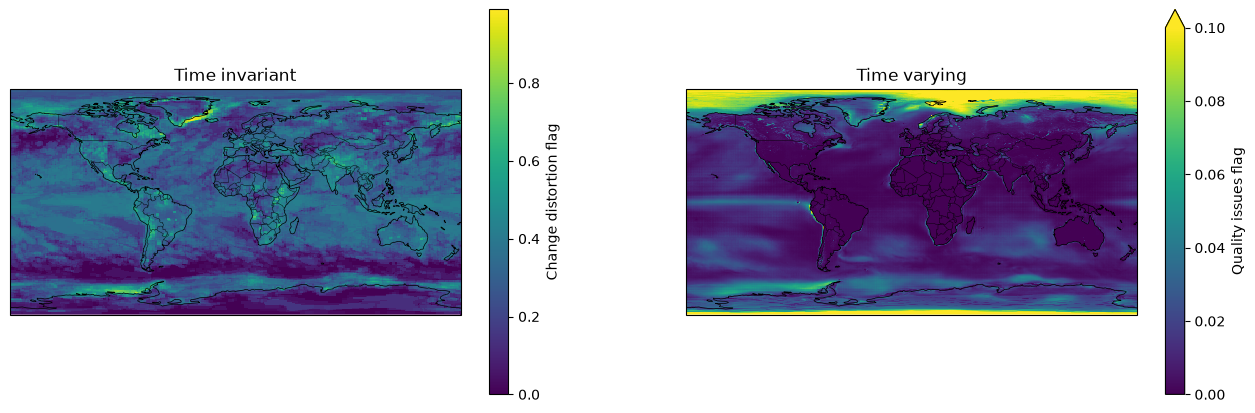

In [18]:
fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(16, 5), subplot_kw={"projection": ccrs.PlateCarree()}
)

ax = axes[0]
(flag_time_invariant_cumulative / n_arrays).plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.viridis
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="k")
ax.set_title("Time invariant")

ax = axes[1]
((flag_time_varying_cumulative / n_time) / n_arrays).plot(
    ax=ax, vmax=0.1, transform=ccrs.PlateCarree(), cmap=plt.cm.viridis
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="k")
ax.set_title("Time varying")
plt.show()

# Zoom in on one example

In [49]:
[trees, tags, _, _, _, tags_np, _, _] = discover_leaves(
    gcms=GCMS, branch=BRANCH, root_dir=ROOT_DIR, store_subset_id=STORE_SUBSET_ID, is_downscaled=True
)

repos: dict[str, icechunk.Repository] = {}
for gcm in GCMS:
    repos[gcm] = icechunk.Repository.open(
        _icechunk_storage_for_path(f"{ROOT_DIR}{gcm}-ERA5-{STORE_SUBSET_ID}.icechunk")
    )

/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store

In [ ]:
tag = "CESM2-WACCM6_pr_g6_1p5k_002_qdmsd"
[gcm, var, scenario, ens, method] = parse_tag(tag)
flags = xr.open_zarr(
    repos[gcm].readonly_session(BRANCH).store,
    group=f"{method}/{scenario}/{var}/{ens}",
    consolidated=False,
)
flag_time_varying = flags[flag_time_varying_name]
flag_time_invariant = flags[flag_time_invariant_name]
# flag_time_varying_land = flag_time_varying * land_mask_u8
# flag_time_invariant_land = flag_time_invariant * land_mask_u8
n_time = flag_time_varying.sizes["time"]

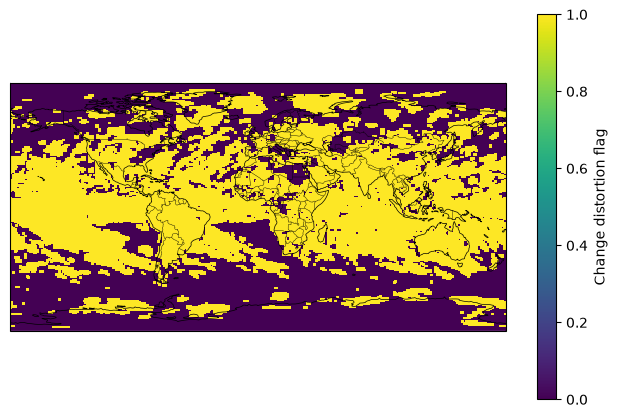

In [53]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
flag_time_invariant.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.viridis)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="k")
plt.show()

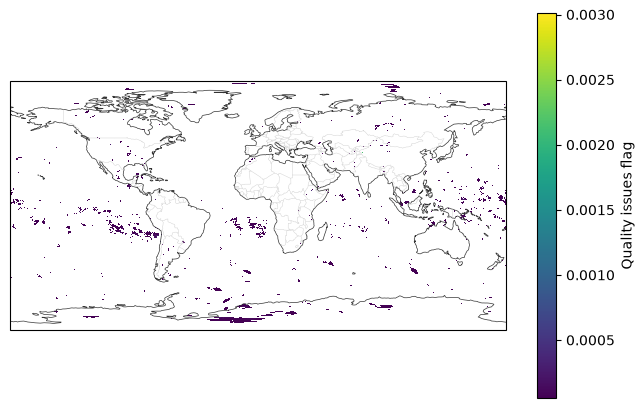

In [55]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
freq_flagged = flag_time_varying.mean(dim="time")
freq_flagged.where(freq_flagged > 0).plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.viridis)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="0.2")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="0.8")
plt.show()

Text(0, 0.5, 'Fraction of land grid cells flagged in 365-day window')

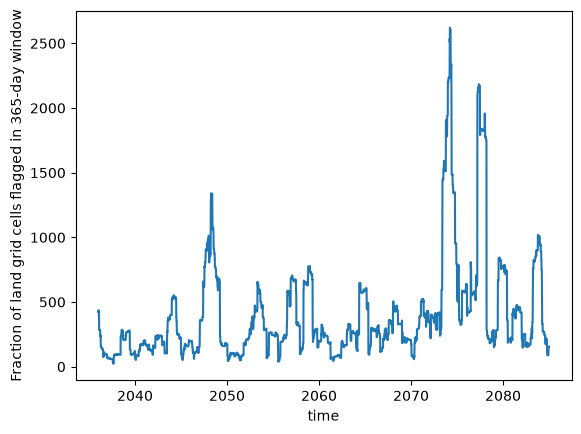

In [56]:
(flag_time_varying.sum(dim=["lat", "lon"]).rolling(time=365).sum()).plot()  # / n_land
plt.ylabel("Fraction of land grid cells flagged in 365-day window")